# Descripción del dataset

### En este dataset encontraremos unos 16.700 solicitantes de crédito, los cuales estaremos clasificando binariamente para evaluar el riesgo crediticio de cada solicitante, especificamente en clasificar si un solicitante presentará dificultades de mora en los siguientes 2 años posteriores a una aprobación o desembolso de crédito. Los datos incluyen indicadores financieros de cada persona al igual que características personales, haciendo más interpretable las variables de cada columna

# Objetivo del Notebook
###

# Descripción de las columnas / variables

###rev_util: Ratio de utilización del crédito renovable (saldo/límite de crédito)
###age: Edad del solicitante

###late_30_59: Número de veces que se ha producido un retraso de entre 30 y 59 días

### debt_ratio: Ratio deuda/ingresos (patrimonio)

### monthly_inc: Ingresos mensuales del prestatario

### open_credit: Número de líneas de crédito y préstamos activos

### late_90: Número de veces que se ha incurrido en un retraso de 90 días o más en un pago

### real_estate: Número de préstamos inmobiliarios o líneas de crédito

### late_60_89: Número de veces que se ha incurrido en un retraso de 60 a 89 días

### dependents: Número de personas a cargo

## **Variable dependiente**

###dlq_2yrs: Variable objetivo que indica si se produjo una morosidad grave en los dos años siguientes (0 = No, 1 = Sí)

Traducción realizada con la versión gratuita del traductor DeepL.com

# 0 - Importamos las librerias necesarias

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
from six import StringIO
import pydotplus
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
import plotly.express as px, plotly.graph_objects as go
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from keras.models import Sequential # Del módulo 'Keras', usado para crear capas y crear neuronas dentro de estas capas; importamos DEL paquete 'models', la función 'Sequential'.
from keras.layers import Dense # Igualmente, de la librería 'Keras', importamos DEL paquete 'layers' (Para crear capas), la función 'Dense'.

# 0.2 - Importamos el dataset

In [ ]:
drive.mount('/content/drive')
solicitantes = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Analítica de Datos/Datasets/Credit Risk Benchmark .xlsx')
solicitantes

Mounted at /content/drive


,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
0,6.999500e-03,38.0,0.0,3.021503e-01,5440.0,4.0,0.0,1.0,0.0,3.0,0
1,7.045917e-01,63.0,0.0,4.714411e-01,8000.0,9.0,0.0,1.0,0.0,0.0,0
2,6.311272e-02,57.0,0.0,6.858628e-02,5000.0,17.0,0.0,0.0,0.0,0.0,0
3,3.683968e-01,68.0,0.0,2.962726e-01,6250.0,16.0,0.0,2.0,0.0,0.0,0
4,9.999999e-01,34.0,1.0,0.000000e+00,3500.0,0.0,0.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...
16709,9.999999e-01,46.0,0.0,1.703980e+07,401.0,3.0,2.0,0.0,0.0,2.0,1
16710,1.135552e+09,41.0,2.0,8.458872e-01,7500.0,12.0,0.0,4.0,1.0,0.0,1
16711,9.201065e-01,31.0,1.0,1.767318e-01,1125.0,4.0,1.0,0.0,0.0,0.0,1
16712,9.838249e-01,55.0,0.0,6.411650e-02,4600.0,2.0,1.0,0.0,0.0,6.0,1


In [ ]:
# Verificamos que no tengamos filas vacías
solicitantes.isnull().sum()
# En este caso vemos que el dataset ya viene limpio y no tenemos que hacer limpieza de datos.

,0
rev_util,0
age,0
late_30_59,0
debt_ratio,0
monthly_inc,0
open_credit,0
late_90,0
real_estate,0
late_60_89,0
dependents,0


# 0.3 - Definimos variables independientes y variable pronóstico (XD y yd)

In [ ]:
XD = solicitantes[['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc', 'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents']]
yd = solicitantes[['dlq_2yrs']]

# Matriz de correlación entre variables

In [ ]:
dfinf = pd.DataFrame (np.column_stack((XD, yd)))
dfinf.columns = [['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc', 'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents', 'dlq_2yrs']]
mCorrelacion = dfinf.corr()
mCorrelacion

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
rev_util,1.000000,-0.096624,0.009306,-0.001728,-0.047962,-0.082937,0.007591,-0.071082,-0.002095,0.041234,0.177316
age,-0.096624,1.000000,-0.069310,0.015982,0.114748,0.227752,-0.074738,0.120877,-0.067653,-0.179859,-0.210701
late_30_59,0.009306,-0.069310,1.000000,-0.004503,-0.047189,-0.102066,0.983371,-0.052397,0.988376,-0.007302,0.118306
debt_ratio,-0.001728,0.015982,-0.004503,1.000000,-0.096416,0.114674,-0.014501,0.198411,-0.011172,-0.019676,0.060588
monthly_inc,-0.047962,0.114748,-0.047189,-0.096416,1.000000,0.233110,-0.054396,0.289536,-0.049675,0.101711,-0.082151
open_credit,-0.082937,0.227752,-0.102066,0.114674,0.233110,1.000000,-0.136509,0.465909,-0.119333,0.014733,-0.049294
late_90,0.007591,-0.074738,0.983371,-0.014501,-0.054396,-0.136509,1.000000,-0.072014,0.990866,-0.011446,0.105697
real_estate,-0.071082,0.120877,-0.052397,0.198411,0.289536,0.465909,-0.072014,1.000000,-0.062414,0.078761,-0.004373
late_60_89,-0.002095,-0.067653,0.988376,-0.011172,-0.049675,-0.119333,0.990866,-0.062414,1.000000,-0.012711,0.089294
dependents,0.041234,-0.179859,-0.007302,-0.019676,0.101711,0.014733,-0.011446,0.078761,-0.012711,1.000000,0.086544


# Graficamos la Matriz de correlación

<Axes: xlabel='None', ylabel='None'>

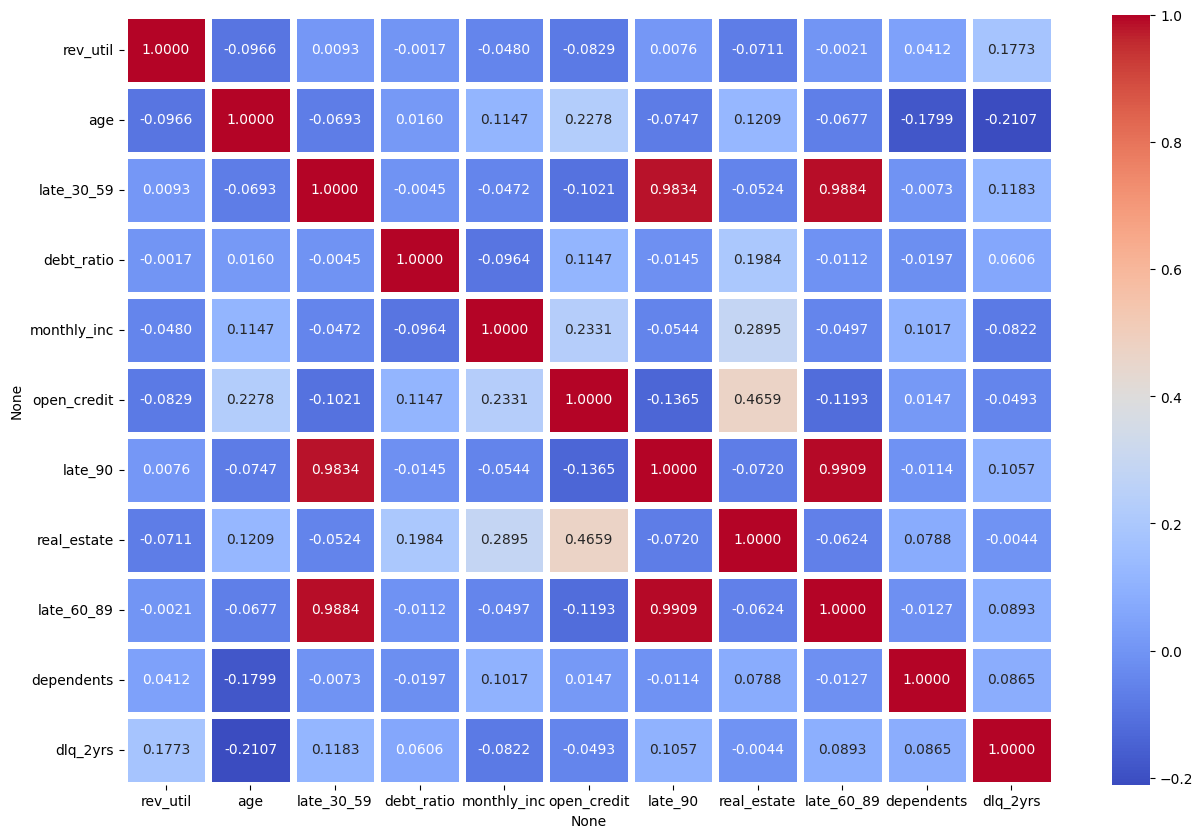

In [ ]:
plt.figure(figsize = (15,10))
sns.heatmap(mCorrelacion, cmap = 'coolwarm',linewidth = 5, annot = True, fmt = '.4f' )

### Podemos concluir que las variables que más correlación entre sí presentan son 'late_30_59' vs 'late_90'. Seguido de otros pares como 'late_30_59' vs 'late_90'. O 'real_estate' vs 'late_60_89'.

### ***Estas variables básicamente están midiendo lo mismo: Comportamiento de mora en diferentes rangos de tiempo.***

### Otro par de variables que también presentan alta correlación (No tan altas como las anteriores todas por encima de 0.9), es el par 'real_estate' vs 'open_credit'. El cual podría dar a entender que las personas entre más lineas de crédito tienen, tienden a tener más bienes raíces.

# Diagrama de disperción con las variables con mayor correlación

(Text(0.5, 0, 'Mora en más de 90 días'), Text(0, 0.5, 'Mora en 60 a 89 días'))

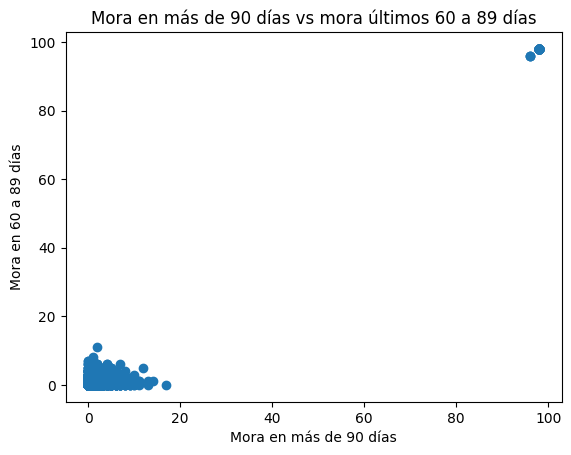

In [ ]:
scatter = plt.scatter(XD['late_90'], XD['late_60_89'])
plt.title('Mora en más de 90 días vs mora últimos 60 a 89 días')
plt.xlabel('Mora en más de 90 días'), plt.ylabel('Mora en 60 a 89 días')
# En términos generales vemos clientes hasta con un score de 20 en el eje X y apróximadamente un score de 10 en el eje Y, en promedio. Evidenciando un patrón consistente de incumplimiento
# Vemos dos casos arriba cercanos a las coordenadas 100,100, indicando casos de mucha mora en ambos rangos de tiempo

# Creamos una variable con el total de mora de los solicitantes

In [ ]:
solicitantes['total_late'] = XD['late_30_59'] + XD['late_60_89'] + XD['late_90']
solicitantes

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs,total_late
0,6.999500e-03,38.0,0.0,3.021503e-01,5440.0,4.0,0.0,1.0,0.0,3.0,0,0.0
1,7.045917e-01,63.0,0.0,4.714411e-01,8000.0,9.0,0.0,1.0,0.0,0.0,0,0.0
2,6.311272e-02,57.0,0.0,6.858628e-02,5000.0,17.0,0.0,0.0,0.0,0.0,0,0.0
3,3.683968e-01,68.0,0.0,2.962726e-01,6250.0,16.0,0.0,2.0,0.0,0.0,0,0.0
4,9.999999e-01,34.0,1.0,0.000000e+00,3500.0,0.0,0.0,0.0,0.0,1.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16709,9.999999e-01,46.0,0.0,1.703980e+07,401.0,3.0,2.0,0.0,0.0,2.0,1,2.0
16710,1.135552e+09,41.0,2.0,8.458872e-01,7500.0,12.0,0.0,4.0,1.0,0.0,1,3.0
16711,9.201065e-01,31.0,1.0,1.767318e-01,1125.0,4.0,1.0,0.0,0.0,0.0,1,2.0
16712,9.838249e-01,55.0,0.0,6.411650e-02,4600.0,2.0,1.0,0.0,0.0,6.0,1,1.0


# Mayor correlación con variable pronóstico

### Una vez ya vistas las variables con mayor correlación entre sí, pasamos a ver las variables con mayor correlación (negativa o positiva) frente a la variable pronóstico 'dlq_2yrs'

### En la matriz de correlación pudimos observar que las variables con mayor correlación fueron 'age' vs 'dlq_2yrs' (En este caso presenta correlación negativa).

<Axes: xlabel='dlq_2yrs', ylabel='age'>

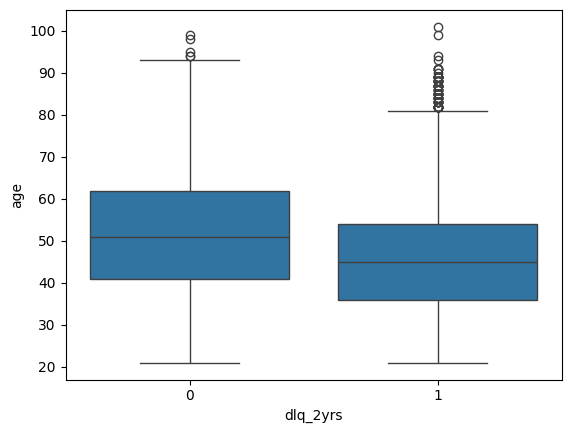

In [ ]:
sns.boxplot(x=yd['dlq_2yrs'], y=XD['age'])
# Vemos como tenemos dos grupos '0' y '1' (Clientes que no hace default y clientes que sí).
# La 'mediana' es la línea que observamos dentro de la caja. Si bien ambas líneas están cerca, la mediana de default '1' se presenta en edades más jóvenes.
# La caja como tal es el 'rango intercuartílico', donde vemos que el grupo de riesgo se encuentra en edades medias-bajas.

In [ ]:
# Podemos incluso segmentar el porcentaje de default por rangos de edad
solicitantes['age_group'] = pd.cut(XD['age'], bins=10)

In [ ]:
pd.crosstab(solicitantes['age_group'], yd['dlq_2yrs'], normalize='index')
# Vemos una relación inversa a medida que bajamos en los rangos de edad. Mostrando así una mayor probabilidad de cumplir con un préstamo a mayor edad del solicitante.
# Esto confirma la relación negativa de (-0.21) entre la edad y la probabilidad de default. Dato que observamos en la matriz de correlación.

dlq_2yrs,0,1
age_group,,
"(20.92, 29.0]",0.367613,0.632387
"(29.0, 37.0]",0.398672,0.601328
"(37.0, 45.0]",0.441168,0.558832
"(45.0, 53.0]",0.461116,0.538884
"(53.0, 61.0]",0.556624,0.443376
"(61.0, 69.0]",0.670213,0.329787
"(69.0, 77.0]",0.713768,0.286232
"(77.0, 85.0]",0.763298,0.236702
"(85.0, 93.0]",0.732759,0.267241


In [ ]:
# Acá podemos observar el dataset inicial pero con las nuevas columnas que contienen información valiosa como lo son 'total_late' y 'age_group'.
solicitantes

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs,total_late,age_group
0,6.999500e-03,38.0,0.0,3.021503e-01,5440.0,4.0,0.0,1.0,0.0,3.0,0,0.0,"(37.0, 45.0]"
1,7.045917e-01,63.0,0.0,4.714411e-01,8000.0,9.0,0.0,1.0,0.0,0.0,0,0.0,"(61.0, 69.0]"
2,6.311272e-02,57.0,0.0,6.858628e-02,5000.0,17.0,0.0,0.0,0.0,0.0,0,0.0,"(53.0, 61.0]"
3,3.683968e-01,68.0,0.0,2.962726e-01,6250.0,16.0,0.0,2.0,0.0,0.0,0,0.0,"(61.0, 69.0]"
4,9.999999e-01,34.0,1.0,0.000000e+00,3500.0,0.0,0.0,0.0,0.0,1.0,0,1.0,"(29.0, 37.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16709,9.999999e-01,46.0,0.0,1.703980e+07,401.0,3.0,2.0,0.0,0.0,2.0,1,2.0,"(45.0, 53.0]"
16710,1.135552e+09,41.0,2.0,8.458872e-01,7500.0,12.0,0.0,4.0,1.0,0.0,1,3.0,"(37.0, 45.0]"
16711,9.201065e-01,31.0,1.0,1.767318e-01,1125.0,4.0,1.0,0.0,0.0,0.0,1,2.0,"(29.0, 37.0]"
16712,9.838249e-01,55.0,0.0,6.411650e-02,4600.0,2.0,1.0,0.0,0.0,6.0,1,1.0,"(53.0, 61.0]"


# 0.4 - Armamos un set óptimo de variables para los modelos de clasificación

### No se trata de usar todas las variables ahora que sabemos cuáles son aquellas que aportan información sin redundancia, y sin aquellas que no presentan mayor valor para la variable pronóstico (como 'real_estate' o 'dependents')

### ***Hacemos una nueva elección de variables que: Tengan relación con dlq_2yrs, no estén altamente correlacionadas entre sí y tengan sentido de negocio***

In [ ]:
# Creamos la variable 'XD2' que contiene el nuevo set óptimo con las variables principales:
XD2 = solicitantes[['age', 'rev_util', 'debt_ratio', 'monthly_inc', 'open_credit', 'total_late']]
XD2

,age,rev_util,debt_ratio,monthly_inc,open_credit,total_late
0,38.0,6.999500e-03,3.021503e-01,5440.0,4.0,0.0
1,63.0,7.045917e-01,4.714411e-01,8000.0,9.0,0.0
2,57.0,6.311272e-02,6.858628e-02,5000.0,17.0,0.0
3,68.0,3.683968e-01,2.962726e-01,6250.0,16.0,0.0
4,34.0,9.999999e-01,0.000000e+00,3500.0,0.0,1.0
...,...,...,...,...,...,...
16709,46.0,9.999999e-01,1.703980e+07,401.0,3.0,2.0
16710,41.0,1.135552e+09,8.458872e-01,7500.0,12.0,3.0
16711,31.0,9.201065e-01,1.767318e-01,1125.0,4.0,2.0
16712,55.0,9.838249e-01,6.411650e-02,4600.0,2.0,1.0


# Creamos una nueva matriz de correlación

In [ ]:
dfinf = pd.DataFrame (np.column_stack((XD2, yd)))
dfinf.columns = [['age', 'rev_util', 'debt_ratio', 'monthly_inc', 'open_credit', 'total_late', 'dlq_2yrs']]
mCorrelacion = dfinf.corr()
mCorrelacion

,age,rev_util,debt_ratio,monthly_inc,open_credit,total_late,dlq_2yrs
age,1.000000,-0.096624,0.015982,0.114748,0.227752,-0.070866,-0.210701
rev_util,-0.096624,1.000000,-0.001728,-0.047962,-0.082937,0.004965,0.177316
debt_ratio,0.015982,-0.001728,1.000000,-0.096416,0.114674,-0.010097,0.060588
monthly_inc,0.114748,-0.047962,-0.096416,1.000000,0.233110,-0.050631,-0.082151
open_credit,0.227752,-0.082937,0.114674,0.233110,1.000000,-0.119797,-0.049294
total_late,-0.070866,0.004965,-0.010097,-0.050631,-0.119797,1.000000,0.104893
dlq_2yrs,-0.210701,0.177316,0.060588,-0.082151,-0.049294,0.104893,1.000000


<Axes: xlabel='None', ylabel='None'>

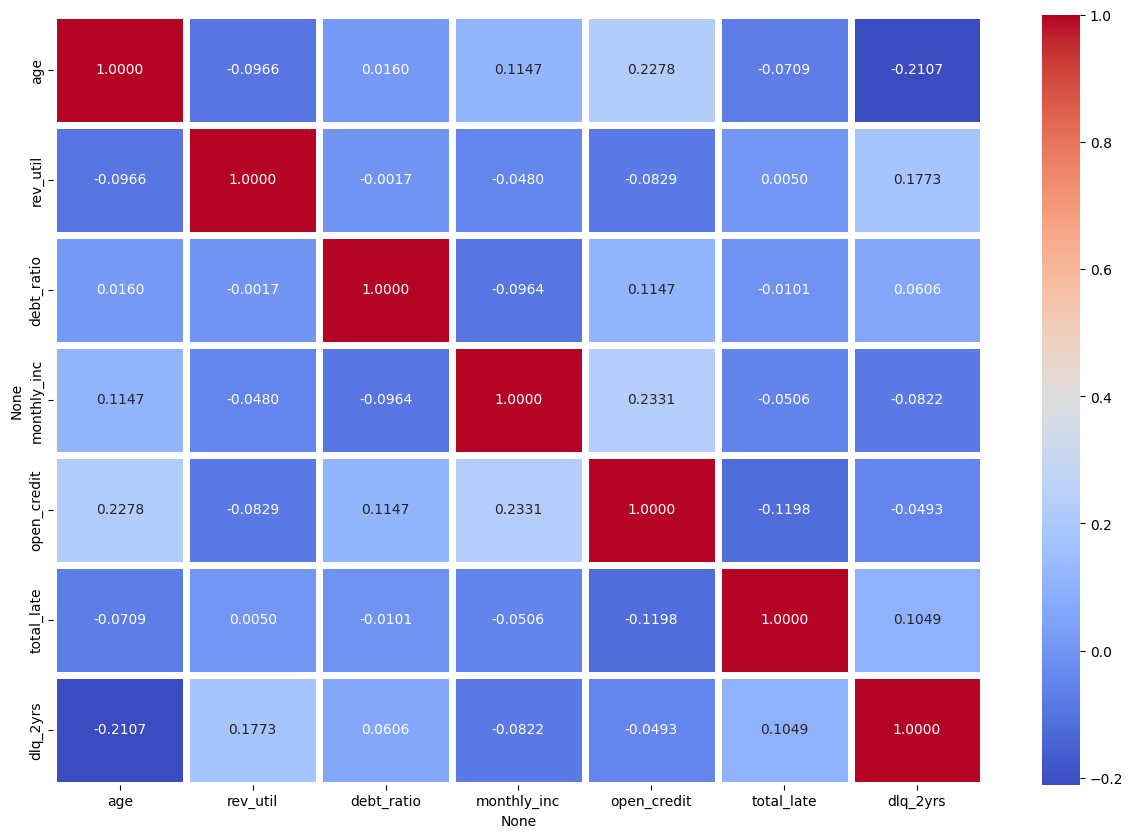

In [ ]:
plt.figure(figsize = (15,10))
sns.heatmap(mCorrelacion, cmap = 'coolwarm',linewidth = 5, annot = True, fmt = '.4f' )

### Ahora vemos una matriz mucho más limpia, permitiéndonos ver como el par de variables independientes con mayor correlación son ***'monthly_inc' vs 'open_credit'***.

### También podemos concluir con esto que las correlaciones observadas con la variable objetivo 'dlq_2yrs' son moderadas. Indicando una alta probabilidad de que el incumplimiento financiero sea un fenómeno multfactorial que no puede ser explicado por una sola variable, sino por la interacción de múltiples características del cliente.

# 0.5 - Convertimos las variablbes 'XD2' y 'yd' a arreglos (arrays)

In [ ]:
# Debemos limpiar los datos ya que hasta ahora son un tipo de dato 'dataframe' y no podemos operarlos:
XDArray = np.array(XD2)
ydArray = np.array(yd)
XDArray, ydArray
# Nos damos cuenta que los datos ya no son 'dataframes' ya que aparecen como 'lista de valores en matriz'.

(array([[3.80000000e+01, 6.99950000e-03, 3.02150340e-01, 5.44000000e+03,
         4.00000000e+00, 0.00000000e+00],
        [6.30000000e+01, 7.04591673e-01, 4.71441070e-01, 8.00000000e+03,
         9.00000000e+00, 0.00000000e+00],
        [5.70000000e+01, 6.31127200e-02, 6.85862830e-02, 5.00000000e+03,
         1.70000000e+01, 0.00000000e+00],
        ...,
        [3.10000000e+01, 9.20106525e-01, 1.76731794e-01, 1.12500000e+03,
         4.00000000e+00, 2.00000000e+00],
        [5.50000000e+01, 9.83824929e-01, 6.41164960e-02, 4.60000000e+03,
         2.00000000e+00, 1.00000000e+00],
        [5.50000000e+01, 2.24710924e-01, 5.72348010e-02, 8.70000000e+03,
         7.00000000e+00, 0.00000000e+00]]),
 array([[0],
        [0],
        [0],
        ...,
        [1],
        [1],
        [1]]))

# 0.6 Normalizamos los valores

In [ ]:
XD2n = XD2/np.max(XD2, axis = 0) # Hacemos esto para obtener valores de 0 o 1. Indicamos que haga la ponderación por columnas, es por esto que usamos el comando 'axis = 0'.
ydn = (1/(np.max(yd)-np.min(yd))) * (yd-np.min(yd))
XD2n, ydn

(            age      rev_util    debt_ratio  monthly_inc  open_credit  \
 0      0.376238  7.907385e-13  3.170487e-11     0.021760     0.070175   
 1      0.623762  7.959822e-11  4.946868e-11     0.032000     0.157895   
 2      0.564356  7.129889e-12  7.196812e-12     0.020000     0.298246   
 3      0.673267  4.161804e-11  3.108811e-11     0.025000     0.280702   
 4      0.336634  1.129707e-10  0.000000e+00     0.014000     0.000000   
 ...         ...           ...           ...          ...          ...   
 16709  0.455446  1.129707e-10  1.788000e-03     0.001604     0.052632   
 16710  0.405941  1.282841e-01  8.875960e-11     0.030000     0.210526   
 16711  0.306931  1.039451e-10  1.854460e-11     0.004500     0.070175   
 16712  0.544554  1.111434e-10  6.727794e-12     0.018400     0.035088   
 16713  0.544554  2.538575e-11  6.005692e-12     0.034800     0.122807   
 
        total_late  
 0        0.000000  
 1        0.000000  
 2        0.000000  
 3        0.000000  
 4   

# **Modelo Naive Bayes**


# 1 - Alojamos el modelo, lo entrenamos y predecimos

In [ ]:
modeloNB = GaussianNB() # Variable que aloja el modelo.
modeloNB.fit(XDArray, ydArray) # Entrenamos el modelo.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [ ]:
ydPredNB = modeloNB.predict(XDArray) # Creamos una predicción de la variable pronóstico en base a las variables independientes (XD).
ydPredNB

array([0, 0, 0, ..., 0, 0, 0])

# 1.2 - Creamos una matriz de confusión

In [ ]:
mc_NB = confusion_matrix(yd, ydPredNB)
mc_NB
# Vemos que en el shell obtenemos una matriz 2x2 lo cual nos confirma que la variable predicha efectivamente es binaria y solo puede ser '0' o '1'.

array([[7953,  404],
       [6922, 1435]])

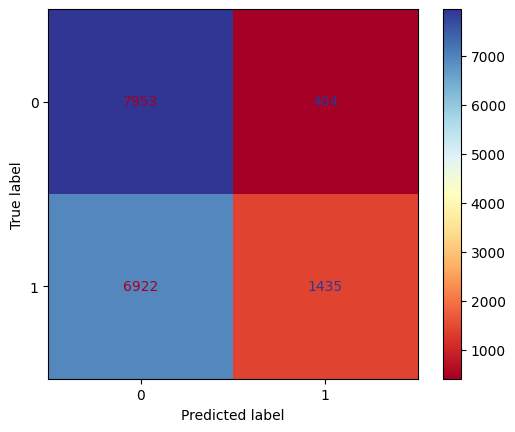

In [ ]:
dispNB = ConfusionMatrixDisplay(mc_NB, display_labels = modeloNB.classes_)
dispNB.plot(cmap = 'RdYlBu')
plt.show()

# 1.3 - Métricas de evaluación


In [ ]:
# Extraigo los valores de la matriz de confusión
# Tengamos en cuenta que la variable 'mc_NB' contiene una 'tabla' con la siguiente forma: 0[VN,FP]
#                                                                                         1[FN,VP]
#                                                                                           0  1
VN_NB = mc_NB [0,0]
FP_NB = mc_NB [0,1]
FN_NB = mc_NB [1,0]
VP_NB = mc_NB [1,1]
# Una vez definidas estas variables, podemos proceder a calcular las métricas de evaluación del modelo

exactitudNB = (VP_NB + VN_NB) / mc_NB.sum() # 'cm.sum' es la manera de hacer la sumatoria de la tabla que contiene la variable 'mc'
errorNB = (FP_NB + FN_NB) / mc_NB.sum()
sensibilidadNB = VP_NB / (VP_NB + FN_NB)
especificidadNB = VN_NB / (VN_NB + FP_NB)
precisiónNB = VP_NB / (VP_NB + FP_NB)
mezclaNB = (exactitudNB + especificidadNB)/2

print(f'La exactitud del modelo es de: {exactitudNB:.2%}')
print(f'El error del modelo es de: {errorNB:.2%}')
print(f'La sensibilidad del modelo es de: {sensibilidadNB:.2%}')
print(f'La especificidad del modelo es de: {especificidadNB:.2%}')
print(f'La precisión del modelo es de: {precisiónNB:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo es de: {mezclaNB:.2%}')

La exactitud del modelo es de: 56.17%
El error del modelo es de: 43.83%
La sensibilidad del modelo es de: 17.17%
La especificidad del modelo es de: 95.17%
La precisión del modelo es de: 78.03%
La mezcla entre exactitud y sensibilidad del modelo es de: 75.67%


# **Modelo Árboles de Decisión**

# 2 - Alojamos el modelo, lo entrenamos y predecimos

In [ ]:
ModArbDec = DecisionTreeClassifier(criterion='gini', max_depth=4)
ModArbDec.fit (XD2, yd)

DecisionTreeClassifier(max_depth=4)

In [ ]:
ydPredModArbDec = ModArbDec.predict(XD2)
ydPredModArbDec

array([0, 1, 0, ..., 1, 1, 0])

# 2.2 - Creamos una matriz de confusión

In [ ]:
mc_ModArbDec = confusion_matrix(yd, ydPredModArbDec)
mc_ModArbDec

array([[6098, 2259],
       [1689, 6668]])

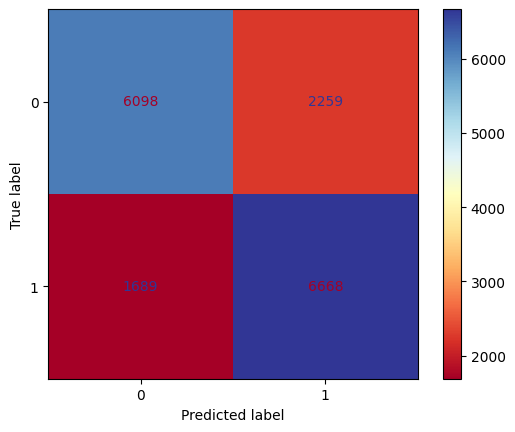

In [ ]:
dispModArbDec = ConfusionMatrixDisplay(mc_ModArbDec, display_labels=modeloNB.classes_)
dispModArbDec.plot(cmap = 'RdYlBu')
plt.show()

# 2.3 Calculamos las métricas de evaluación del modelo

In [ ]:
# Extraigo los valores de la matriz de confusión
# Tengamos en cuenta que la variable 'mc_NB' contiene una 'tabla' con la siguiente forma: 0[VN,FP]
#                                                                                         1[FN,VP]
#                                                                                           0  1
VN_ModArbDec = mc_ModArbDec [0,0]
FP_ModArbDec = mc_ModArbDec [0,1]
FN_ModArbDec = mc_ModArbDec [1,0]
VP_ModArbDec = mc_ModArbDec [1,1]
# Una vez definidas estas variables, podemos proceder a calcular las métricas de evaluación del modelo

exactitudModArbDec = (VP_ModArbDec + VN_ModArbDec) / mc_ModArbDec.sum() # 'cm.sum' es la manera de hacer la sumatoria de la tabla que contiene la variable 'mc'
errorModArbDec = (FP_ModArbDec + FN_ModArbDec) / mc_ModArbDec.sum()
sensibilidadModArbDec = VP_ModArbDec / (VP_ModArbDec + FN_ModArbDec)
especificidadModArbDec = VN_ModArbDec / (VN_ModArbDec + FP_ModArbDec)
precisiónModArbDec = VP_ModArbDec / (VP_ModArbDec + FP_ModArbDec)
mezclaModArbDec = (exactitudModArbDec + especificidadModArbDec)/2

print(f'La exactitud del modelo es de: {exactitudModArbDec:.2%}')
print(f'El error del modelo es de: {errorModArbDec:.2%}')
print(f'La sensibilidad del modelo es de: {sensibilidadModArbDec:.2%}')
print(f'La especificidad del modelo es de: {especificidadModArbDec:.2%}')
print(f'La precisión del modelo es de: {precisiónModArbDec:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo es de: {mezclaModArbDec:.2%}')

La exactitud del modelo es de: 76.38%
El error del modelo es de: 23.62%
La sensibilidad del modelo es de: 79.79%
La especificidad del modelo es de: 72.97%
La precisión del modelo es de: 74.69%
La mezcla entre exactitud y sensibilidad del modelo es de: 74.67%


# 2.4 - Graficamos el modelo

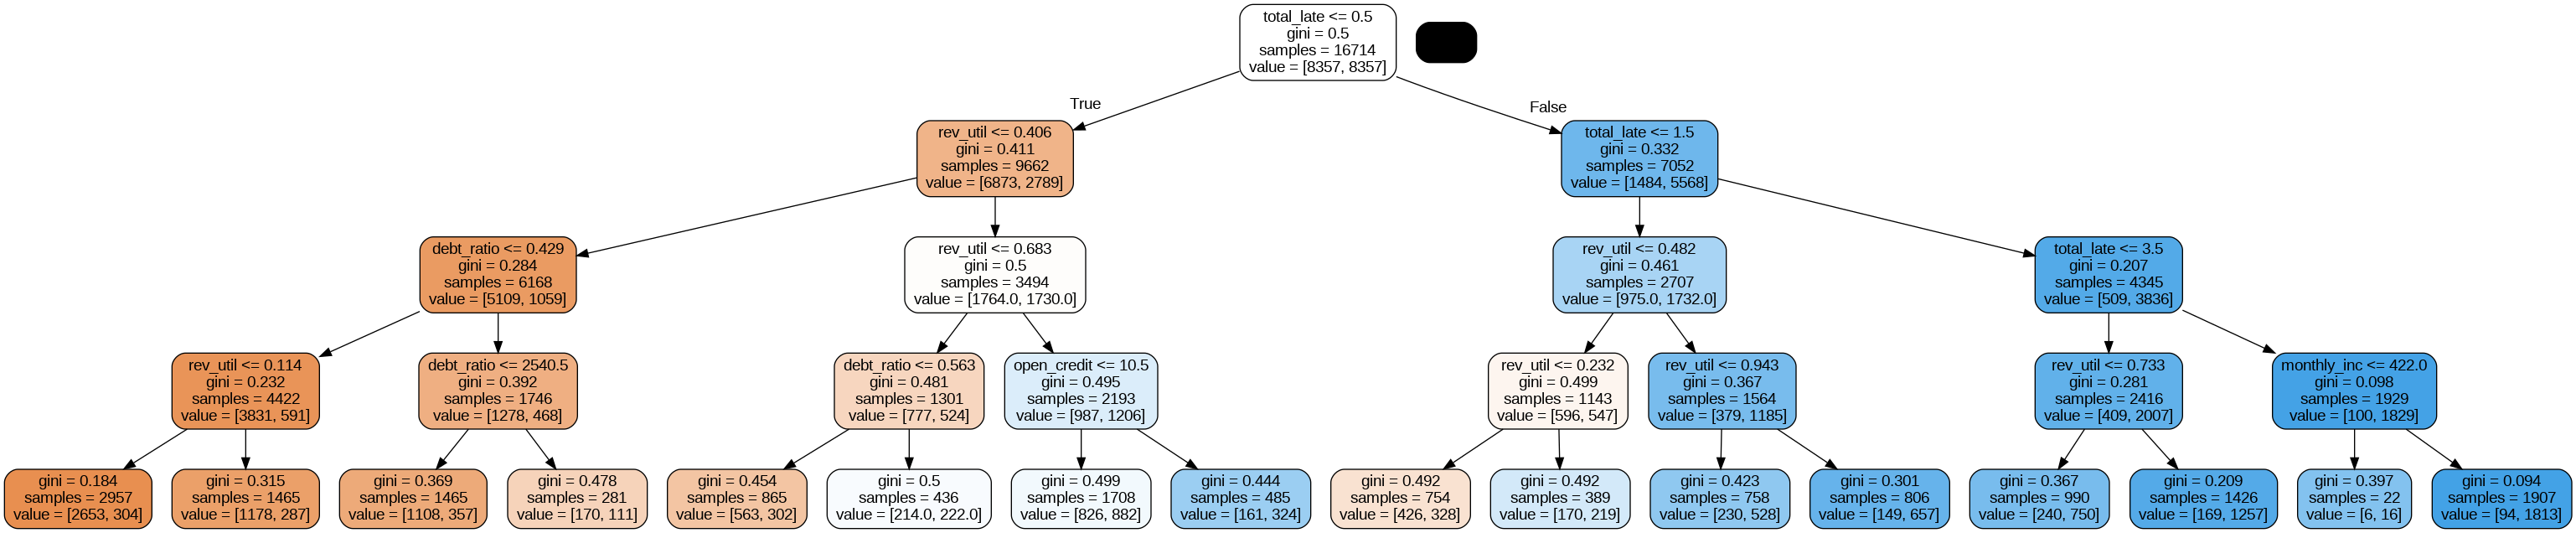

In [ ]:
var = ['age', 'rev_util', 'debt_ratio', 'monthly_inc', 'open_credit', 'total_late']
dot_data = StringIO()
export_graphviz (ModArbDec, out_file=dot_data, feature_names=var, filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())
# A primera vista no encontramos ningún nodo puro (es decir, con coeficiente 'gini' = 0.0)

In [ ]:
# Vemos en la lista 'value' el orden binario como el modelo segmenta
ModArbDec.classes_

array([0, 1])

# **Modelo K Nearest Neighbors**

# 3 - Alojamos el modelo, lo entrenamos y predecimos

In [ ]:
KNNmodel = KNeighborsClassifier(n_neighbors=10)
KNNmodel.fit(XD2, yd)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=10)

In [ ]:
ydPredKNNModel= KNNmodel.predict(XD2)
ydPredKNNModel

array([0, 0, 0, ..., 1, 0, 1])

# 3.2 - Implementamos la matriz de confusión y de correlación

# 3.3 Creamos una matriz de confusión

In [ ]:
mc_KNNModel = confusion_matrix (yd, ydPredKNNModel)
mc_KNNModel

array([[6858, 1499],
       [3627, 4730]])

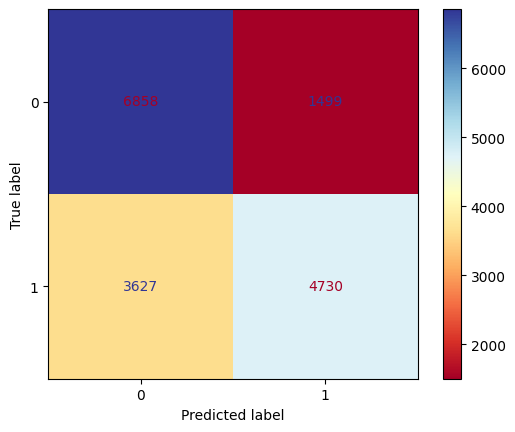

In [ ]:
dispKNNModel = ConfusionMatrixDisplay(mc_KNNModel, display_labels=modeloNB.classes_)
dispKNNModel.plot(cmap = 'RdYlBu')
plt.show()

# 3.4 - Calculamos las métricas de evaluación del modelo

In [ ]:
# Extraigo los valores de la matriz de confusión
# Tengamos en cuenta que la variable 'mc_NB' contiene una 'tabla' con la siguiente forma: 0[VN,FP]
#                                                                                         1[FN,VP]
#                                                                                           0  1
VN_KNNModel = mc_KNNModel [0,0]
FP_KNNModel = mc_KNNModel [0,1]
FN_KNNModel = mc_KNNModel [1,0]
VP_KNNModel = mc_KNNModel [1,1]

# Una vez definidas estas variables, podemos proceder a calcular las métricas de evaluación del modelo.

exactitudKNNModel = (VP_KNNModel + VN_KNNModel) / mc_KNNModel.sum() # 'cm.sum' es la manera de hacer la sumatoria de la tabla que contiene la variable 'mc'.
errorKNNModel = (FP_KNNModel + FN_KNNModel) / mc_KNNModel.sum()
sensibilidadKNNModel = VP_KNNModel / (VP_KNNModel + FN_KNNModel)
especificidadKNNModel = VN_KNNModel / (VN_KNNModel + FP_KNNModel)
precisiónKNNModel = VP_KNNModel / (VP_KNNModel + FP_KNNModel)
mezclaKNNModel = (exactitudKNNModel + especificidadKNNModel)/2

print(f'La exactitud del modelo es de: {exactitudKNNModel:.2%}')
print(f'El error del modelo es de: {errorKNNModel:.2%}')
print(f'La sensibilidad del modelo es de: {sensibilidadKNNModel:.2%}')
print(f'La especificidad del modelo es de: {especificidadKNNModel:.2%}')
print(f'La precisión del modelo es de: {precisiónKNNModel:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo es de: {mezclaKNNModel:.2%}')

La exactitud del modelo es de: 69.33%
El error del modelo es de: 30.67%
La sensibilidad del modelo es de: 56.60%
La especificidad del modelo es de: 82.06%
La precisión del modelo es de: 75.94%
La mezcla entre exactitud y sensibilidad del modelo es de: 75.70%


# Comparamos las mezclas

In [ ]:
print(f'La mezcla entre exactitud y sensibilidad del modelo Naive Bayes es de: {mezclaNB:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo de Árboles de Decisión es de: {mezclaModArbDec:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo K Nearest Neighbors es de: {mezclaKNNModel:.2%}')

La mezcla entre exactitud y sensibilidad del modelo Naive Bayes es de: 75.67%
La mezcla entre exactitud y sensibilidad del modelo de Árboles de Decisión es de: 74.67%
La mezcla entre exactitud y sensibilidad del modelo K Nearest Neighbors es de: 75.70%


# Elección del modelo

### A simple vista vemos que el modelo KNN es el modelo con mejor porcentaje de mezcla, sin embargo al remitirnos a las métricas de evaluación del modelo, observamos que tiene porcentajes bajos en algunos de sus resultados individuales (La exactitud del modelo es de: 69.33%. El error del modelo es de: 30.67%. La sensibilidad del modelo es de: 56.60%)

### Al realizar lo mismo con el modelo Naive Bayes, que tiene la segunda posición entre las mejores mezclas, observamos que presenta la misma problemática, varias métricas de evaluación con resultados inferiores al 75% como umbral de precisión para métricas (La exactitud del modelo es de: 56.17%. El error del modelo es de: 43.83%. La sensibilidad del modelo es de: 17.17%). **En este caso vemos una tasa de 'error' bastante alta.**

### Revisando el modelo Árboles de decisión, vemos que si bien en su mezcla no está tan cercana al 75% (por poco), sus parámetros individuales terminan por ser todos valores por encima del 70%, lo cual hace que esta sea una de las razones por las que podríamos considerar elegir este modelo como el más apropiado para poder clasificar a los 16.700 solicitantes.

### No solo sus métricas de evaluación hacen que sea el modelo más apto para este caso. Sino el conocimiento que tuvimos inicialmente con la *segunda matriz de correlación*, donde notamos que el incumplimiento financiero de un solicitante, en mayor medida es denotado por múltiples factores, **haciendo que el modelo de Árboles de decisión sea el más optimo ya que nos ofrece la interpretación de reglas para conocer y entender mejor cada posible escenario**

# **Clusterizamos con K Means**

# 4 - Alojamos el modelo y lo entrenamos con 'XD2n' (Valores ya normalizados)

In [ ]:
k = 5
KMeansModel = KMeans(n_clusters = k, init='random', random_state=42)
scaler = StandardScaler()
XD2_scaled = scaler.fit_transform(XD2)
KMeansModel.fit(XD2n)
labels = KMeansModel.labels_

# 4.2 - Asignamos y almacenamos dentro de variables, las etiquetas y centroides

In [ ]:
# Obtengo del modelo los clústeres y los centroides:
labels = KMeansModel.labels_
centroids_scaled = KMeansModel.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

labels, centroids
# Un clúster es una nube de puntos. Un centroide es como un promedio de esos puntos, es decir, un punto imaginario que es el promedio de esos puntos del clúster.
# Nos permite saber qué tan lejos están los puntos en la nube, del centroide.

(array([3, 4, 1, ..., 3, 0, 0], dtype=int32),
 array([[5.56244774e+01, 7.86353979e+07, 9.63710859e+07, 6.27112837e+03,
         9.13738358e+00, 2.80354504e+00],
        [5.59470162e+01, 7.66113050e+07, 1.03748480e+08, 6.32083878e+03,
         1.01038804e+01, 2.78636696e+00],
        [5.38959193e+01, 7.54908458e+07, 9.30596799e+07, 6.17427299e+03,
         8.50476817e+00, 2.40828373e+01],
        [5.33940208e+01, 7.98277283e+07, 9.63797356e+07, 6.22700714e+03,
         9.06916862e+00, 2.80370217e+00],
        [5.82642633e+01, 7.66433612e+07, 9.68435192e+07, 6.25975136e+03,
         9.28634616e+00, 2.76068249e+00]]))

#4.3 - Graficamos clústeres

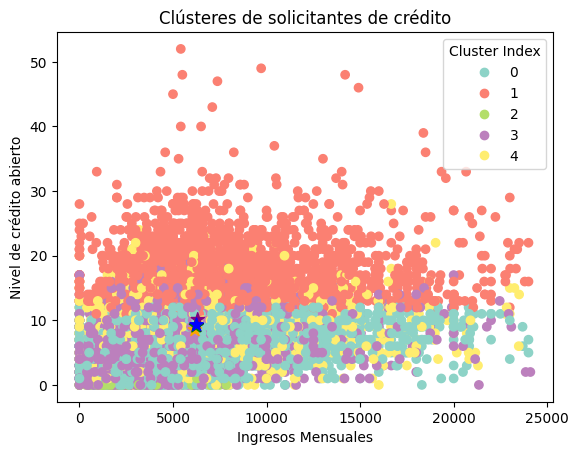

In [ ]:
# Filtramos outliers para visualizar mejor
mask = (XD2['monthly_inc'] < XD2['monthly_inc'].quantile(0.99))

scatter = plt.scatter(
    XD2.loc[mask, 'monthly_inc'],
    XD2.loc[mask, 'open_credit'],
    c=labels[mask], cmap='Set3'
)
colors = ['black', 'purple', 'orange', 'green', 'blue']
plt.scatter(centroids[:,3], # 'monthly_inc'
            centroids[:,4], # 'open_credit'
            facecolor = colors, marker = '*', s = 100) #
plt.xlabel('Ingresos Mensuales'), plt.ylabel('Nivel de crédito abierto') # Agregamos etiquetas a las variables del eje X y Y.
plt.legend(title = 'Cluster Index', *scatter.legend_elements()) # Extraemos los clústeres contenidos en el scatter.
plt.title('Clústeres de solicitantes de crédito') # Agregamos un titulo que explique la gráfica.
plt.show()

# 4.4 - Generamos los informes de los clústeres

In [ ]:
# Necesito completar el dataframe original colocándole una nueva columna con los clústeres para cada asesor.
AAA = XD2.copy(deep=True)
AAA.loc [:, 'dlq_2yrs'] = yd
AAA.loc [:, 'cluster'] = labels
AAA

,age,rev_util,debt_ratio,monthly_inc,open_credit,total_late,dlq_2yrs,cluster
0,38.0,6.999500e-03,3.021503e-01,5440.0,4.0,0.0,0,3
1,63.0,7.045917e-01,4.714411e-01,8000.0,9.0,0.0,0,4
2,57.0,6.311272e-02,6.858628e-02,5000.0,17.0,0.0,0,1
3,68.0,3.683968e-01,2.962726e-01,6250.0,16.0,0.0,0,4
4,34.0,9.999999e-01,0.000000e+00,3500.0,0.0,1.0,0,3
...,...,...,...,...,...,...,...,...
16709,46.0,9.999999e-01,1.703980e+07,401.0,3.0,2.0,1,0
16710,41.0,1.135552e+09,8.458872e-01,7500.0,12.0,3.0,1,0
16711,31.0,9.201065e-01,1.767318e-01,1125.0,4.0,2.0,1,3
16712,55.0,9.838249e-01,6.411650e-02,4600.0,2.0,1.0,1,0


In [ ]:
# Contamos cuántos de cada industria hay por cada clúster:
counts_0 = AAA.groupby('cluster').agg({"dlq_2yrs": lambda x: (x==0).sum()}) # Cuenta de dlq_2yrs (0).
counts_1 = AAA.groupby('cluster').agg({"dlq_2yrs": lambda x: (x==1).sum()}) # Cuenta de dlq_2yrs (1).
df = pd.DataFrame (np.column_stack ((counts_0, counts_1)))
df.columns = ['Cumplimiento en pago', 'Mora en pago']
df['Total'] = df.sum(axis=1)
df['ProbPaga'] = (df ['Cumplimiento en pago']/df['Total']).map('{:,.2%}'.format)
df['ProbMora'] = (df ['Mora en pago']/df['Total']).map('{:,.2%}'.format)
df

,Cumplimiento en pago,Mora en pago,Total,ProbPaga,ProbMora
0,2664,2770,5434,49.02%,50.98%
1,1363,1439,2802,48.64%,51.36%
2,5,84,89,5.62%,94.38%
3,2037,3047,5084,40.07%,59.93%
4,2288,1017,3305,69.23%,30.77%


# 4.5 - Graficamos en 3D

In [ ]:
# Agregamos una tercera variable para graficar el eje Z, en este caso vemos en la matriz de correlación que la siguiente variable con mayor coeficiente es 'feedback'
fig = px.scatter_3d(AAA.astype({'cluster':str}), 'monthly_inc', 'open_credit', 'age', color = 'cluster')
fig = go.Figure(fig)
# Ploteo
fig.show()
# Vemos como podemos graficar en 3 dimensiones el gráfico e incluso podemos interactuar y ver detalles de los 'clústers'.
# Grafico los centroides:
fig.add_trace(go.Scatter3d(x = centroids [:,1].tolist(), y =  centroids [:,2].tolist(), z = centroids [:,3].tolist(), name = 'Centroides', marker = dict (color='black'), mode='markers'))

### Concluímos que los clústeres donde se segmentan las personas en mayor medida son los clústeres 3 y 4.

### Sin embargo, viendo en cada clúster la mayor probabilidad de pagar, encontramos que los clústeres 4 y 0 son los que tienen menor probabilidad de entrar en mora y por tanto, mayor probabilidad de cumplir con sus pagos.

### El único clúster que tiene mayor probabilidad total de pagar que de entrar en mora es el clúster 4.

# **Modelo MADALINE (Multi-Adaptive Linear)**

# 5 - Alojamos el modelo y lo entrenamos con 'XD2n' (Valores ya normalizados)

In [ ]:
# Implementamos el modelo teniendo en cuenta el número de capas y el número de valores de entrada (XD).
# En este caso tenemos 6 variables.
NE_MADALINE = 6 # Número de entradas (Depende de la cantidad de variables independientes).
MADALINE = Sequential() # Acá alojaremos los cortex cerebralex.

# CAPA 1
MADALINE.add(Dense(16, activation = 'relu', use_bias = False, input_dim = NE_MADALINE ))

# CAPA 2
MADALINE.add(Dense(8, activation = 'relu', use_bias = False, input_dim = NE_MADALINE ))

# CAPA 3
MADALINE.add(Dense(1, activation='sigmoid', use_bias = False))

MADALINE.compile(optimizer = 'adagrad', loss = 'binary_crossentropy')
MADALINE.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232 (928.00 B)

 Trainable params: 232 (928.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historical_MADALINE = MADALINE.fit(XD2n, ydn, epochs = 300)  # Penaliza más los errores en clase 1 # la variable va a almacenar el histórico de la forma en la que se entrena el módelo.
#                                             Adicionalmente como tercer parámetro, definimos las iteraciones (epochs).
# Las iteraciones se hacen con el fin de gradualmente disminuir el error del módelo

Epoch 1/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.6933
Epoch 2/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6927
Epoch 3/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6923
Epoch 4/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6921
Epoch 5/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6918
Epoch 6/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6917
Epoch 7/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6915
Epoch 8/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6914
Epoch 9/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6913
Epoch 10/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6912
Epoch 11/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6911
Epoch 12/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6910
Epoch 13/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6910
Epoch 14/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6909
Epoch 15/300
523/523 ━━━━━━━━━━━━━━━━━━━━ 1

# 5.2 - Predecimos y comparamos

In [ ]:
# Ahora veremos qué tan bien predice el modelo (ydPred en otros modelos)
ys_MADALINE = MADALINE.predict(XD2n)
ys_MADALINE

523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.46419367],
       [0.4478076 ],
       [0.47786778],
       ...,
       [0.47881004],
       [0.44450444],
       [0.45080683]], dtype=float32)

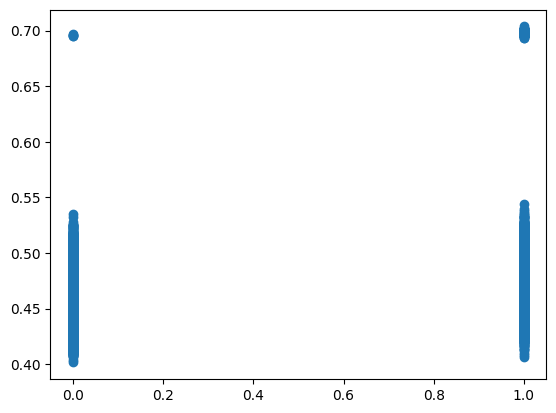

In [ ]:
plt.figure()
plt.scatter(ydn, ys_MADALINE)
plt.show()

# 5.3 - Creamos matriz de correlación y pesos (W) / Efectos independientes

In [ ]:
# Creamos una matriz de correlación:
df_MADALINE = pd.DataFrame(np.column_stack((ydn,ys_MADALINE)))
df_MADALINE.corr()

,0,1
0,1.000000,0.273678
1,0.273678,1.000000


In [ ]:
# Obtenemos los pesos (W) / efectos independientes de la primera capa
W1_MADALINE = MADALINE.layers[0].get_weights()
W1_MADALINE

[array([[ 0.27500096, -0.05819793,  0.23955365, -0.3915304 ,  0.27249512,
          0.23885366, -0.25015888, -0.28753087,  0.5942038 , -0.14467768,
          0.40015098,  0.30428642, -0.0141529 ,  0.23136453, -0.4896578 ,
         -0.168316  ],
        [-0.03400797, -0.15646753,  0.62858564,  0.36816317,  0.08181526,
         -0.53435993, -0.407233  , -0.01411772, -0.28819975,  0.09453013,
         -0.6454211 ,  0.6644982 ,  0.19665532, -0.02501139, -0.19311778,
          0.217816  ],
        [ 0.20068614, -0.36832935,  0.1573407 , -0.23004109, -0.45845267,
         -0.4382102 , -0.0850375 , -0.04576066, -0.37568414, -0.18366063,
          0.31282723, -0.4547002 , -0.3047022 , -0.02463622,  0.29360104,
         -0.3110742 ],
        [-0.07904667, -0.35093108,  0.04511765,  0.37369063, -0.4821615 ,
         -0.32202303, -0.00912393,  0.181506  ,  0.0847462 , -0.01788275,
          0.5669317 ,  0.4019093 , -0.5023283 ,  0.3824911 ,  0.1042733 ,
         -0.5213781 ],
        [-0.29135716

In [ ]:
# Obtenemos los pesos (W) / efectos independientes de la segunda capa
W2_MADALINE = MADALINE.layers[1].get_weights()
W2_MADALINE

[array([[ 0.46769688,  0.1324668 , -0.36300957,  0.4243708 , -0.32259494,
          0.19104595, -0.11866705, -0.2512188 ],
        [-0.10940135, -0.0586979 ,  0.42579448, -0.16141514, -0.44561744,
          0.13643207, -0.47379127,  0.18200707],
        [-0.41168782, -0.5092537 , -0.4112544 ,  0.249123  , -0.27966997,
          0.2845053 , -0.0043333 ,  0.33293155],
        [-0.19972046, -0.07004795,  0.33259106,  0.02120895,  0.34178534,
          0.46250698,  0.1920641 , -0.12110031],
        [-0.24052727,  0.13283086,  0.48639452,  0.25688034, -0.07420323,
          0.2548381 ,  0.41957757,  0.27141833],
        [ 0.52179384,  0.17092335,  0.36053944,  0.03304559, -0.3867044 ,
         -0.11992224, -0.3832695 ,  0.24237032],
        [ 0.3159615 ,  0.34548622, -0.3995775 , -0.04358496, -0.24736857,
         -0.48732677,  0.43910852, -0.29572245],
        [-0.45474637,  0.23784645,  0.20507574,  0.47606307, -0.4095199 ,
          0.00255058,  0.01679708,  0.4264636 ],
        [ 0.2982

In [ ]:
# Obtenemos los pesos (W) / efectos independientes de la tercera capa
W3_MADALINE = MADALINE.layers[2].get_weights()
W3_MADALINE

[array([[-0.7585171 ],
        [-0.74746895],
        [ 0.02999192],
        [ 0.2935719 ],
        [-0.2081965 ],
        [ 0.08448762],
        [ 0.6483493 ],
        [-0.60204196]], dtype=float32)]

### Suma del producto de 𝑤𝑗𝑖 ∗ 𝐶𝑗

In [ ]:
W1 = MADALINE.layers[0].get_weights()[0]
W2 = MADALINE.layers[1].get_weights()[0]
W3 = MADALINE.layers[2].get_weights()[0]

contribucion = np.abs(W1 @ W2 @ W3).flatten()

variables = ['age', 'rev_util', 'debt_ratio', 'monthly_inc', 'open_credit', 'total_late']

for var, val in zip(variables, contribucion):
    print(f"{var}: {val:.4f}")

print(f"\nMayor contribución: {variables[np.argmax(contribucion)]}")

age: 0.2966
rev_util: 1.3494
debt_ratio: 0.2053
monthly_inc: 0.2954
open_credit: 0.7600
total_late: 2.3609

Mayor contribución: total_late


# **Arquitectura de la red neuronal**
### Red neuronal de 3 capas: entrada (6 variables), dos capas ocultas con 'relu', capa de salida con sigmoid y binary_crossentropy. Totalizando 3 conjuntos de pesos aprendidos (W1, W2, W3).

### La gráfica de dispersión muestra "huecos" entre ambas columnas, indicando que el modelo comienza a distinguir zonas de probabilidad diferenciadas entre clase 0 y clase 1. Sin embargo, ambas columnas aún comparten el rango ~0.40–0.70, lo que significa que la separación no es completa.

# **Conclusiones finales**
### Elegimos el modelo MADALINE en lugar de ADALINE, ya que el primero supera en capacidad predictiva gracias a las capas ocultas que capturan interacciones **no lineales** entre variables. (Característica que descubrimos en un inicio cuando definimos las nuevas variables independientes)

### **total_late como mayor contribuyente** *(Ver Suma del producto de 𝑤𝑗𝑖 ∗ 𝐶𝑗)*, es consistente con el análisis exploratorio inicial, donde las variables de mora en distintos rangos de tiempo mostraban las correlaciones más altas entre sí.

### No obstante, para este problema de riesgo crediticio, el modelo de Árboles de Decisión sigue siendo más interpretable y con métricas individuales más sólidas, lo cual es crítico en contextos financieros donde las decisiones deben ser explicables.